In [1]:
import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint

ImportError: cannot import name 'ImageDataGenerator' from 'keras.preprocessing.image' (C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\api\preprocessing\image\__init__.py)

In [2]:
import keras
print(keras.__version__)

3.5.0


In [3]:
# import libraries
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint

# for accuracy loss grap
import matplotlib.pyplot as plt
import tensorflow

In [4]:
print(keras.__version__)
print(tensorflow.__version__)

3.5.0
2.17.0


In [5]:
train_data_path ="C:/Users/DELL/Desktop/face mask/Dataset/Train"
validation_data_path = "C:/Users/DELL/Desktop/face mask/Dataset/Validation"

In [6]:
def plotImgs(images_arr):
    fig , axes =plt.subplots(1,5, figsize=(20,20))
    axes =axes.flatten()
    for img,ax in zip(images_arr,axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()


In [7]:
# this is the agumentation configuration we will use for training
# it generate more image using below parameter
training_datagen = ImageDataGenerator(rescale=1./255,
                                      rotation_range=40,
                                      width_shift_range=0.2,
                                      height_shift_range=0.2,
                                      shear_range=0.2,
                                      zoom_range=0.2,
                                      horizontal_flip=True,
                                      fill_mode='nearest')


# this is generator that will read picture found in 
# at train_data_path and indefinitely generate 
# batches of augmented image data
training_data = training_datagen.flow_from_directory(train_data_path,# this is the target directory
                                                     target_size=(200, 200),  # all images will be resized to 150*150
                                                     batch_size=128,
                                                     class_mode='binary')# since we use binary_crossentropy loss, we need binary labels

Found 10000 images belonging to 2 classes.


In [8]:
training_data.class_indices

{'WithMask': 0, 'WithoutMask': 1}

In [9]:
# this is the agumentation configuration we will use for validation:
# only rescaling
valid_datagen =  ImageDataGenerator(rescale=1./255)

# This is a similar generator, for validation data
valid_data = valid_datagen.flow_from_directory(validation_data_path,
                                          target_size=(200, 200),
                                          batch_size=128,
                                          class_mode='binary')


Found 800 images belonging to 2 classes.


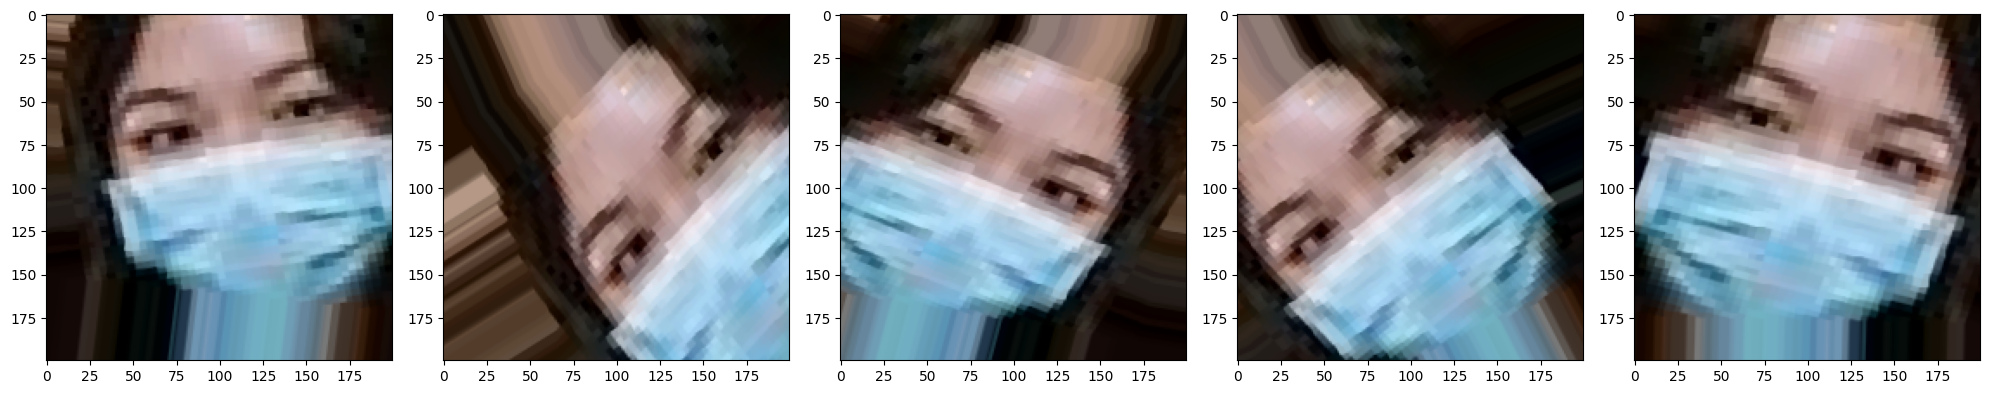

In [10]:
#showing agumented images
images = [training_data[0][0][0] for i in range(5)]
plotImgs(images)

In [11]:
# save best model using vall accuracy
model_path = model_path = "C:/Users/DELL/Desktop/face mask/Dataset/Test/best_model.keras"
checkpoint= ModelCheckpoint ( model_path, monitor='val_accuracy', verbose=1,save_best_only=True,mode='max')
callbacks_list = [checkpoint]

In [12]:
# Building cnn model
cnn_model = keras.models.Sequential([
    keras.layers.Conv2D(filters=32, kernel_size=5, input_shape=[200,200,3]),
    keras.layers.MaxPooling2D(pool_size=(4,4)),
    keras.layers.Conv2D(filters=64, kernel_size=4),
    keras.layers.MaxPooling2D(pool_size=(3,3)),
    keras.layers.Conv2D(filters=128, kernel_size=3),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(filters=256, kernel_size=2),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),# neural network beuding
    keras.layers.Dense(units=128, activation='relu'), # input layers
    keras.layers.Dropout(0.1),
    keras.layers.Dense(units=256, activation='relu'), # input layers
    keras.layers.Dropout(0.25),
    keras.layers.Dense(units=2, activation='softmax') # input layers

])
from keras.optimizers import Adam

# Compile the model with the correct parameter name
cnn_model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# train cnn model
history = cnn_model.fit(training_data,
                        epochs=10,
                        verbose=1,
                        validation_data= valid_data,
                        callbacks= callbacks_list)# time start 14.25

Epoch 1/50


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


24/79 ━━━━━━━━━━━━━━━━━━━━ 1:25 2s/step - accuracy: 0.6220 - loss: 0.6193

In [13]:
cnn_model.save("C:/Users/DELL/Desktop/face mask/Dataset/Test/best_model.keras")

In [14]:
import matplotlib.pyplot as plt
# plot the loss
plt.plot(cnn_model.history['loss'], label='train loss')
plt.plot(cnn_model.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('lossVal_loss')

# plot accuracy
plt.plot(cnn_model.history['accuracy'], label='train acc')
plt.plot(cnn_model.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('accVal_acc')


TypeError: 'History' object is not subscriptable